In [ ]:
!pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
import fastf1
import pandas as pd
import os

os.makedirs('cache',exist_ok=True)
fastf1.Cache.enable_cache('cache')

session = fastf1.get_session(2026, 'Miami', 'R')
session.load()

laps = session.laps
laps.head()

core           INFO 	Loading data for Miami Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Miami Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data.

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:59:00.108000,NOR,1,0 days 00:01:38.115000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:34.453000,...,True,McLaren,0 days 00:57:21.749000,2026-05-03 17:04:02.494,1,3.0,False,,False,False
1,0 days 01:00:32.878000,NOR,1,0 days 00:01:32.770000,2.0,1.0,NaT,NaT,0 days 00:00:32.593000,0 days 00:00:34.600000,...,True,McLaren,0 days 00:59:00.108000,2026-05-03 17:05:40.853,1,3.0,False,,False,True
2,0 days 01:02:06.141000,NOR,1,0 days 00:01:33.263000,3.0,1.0,NaT,NaT,0 days 00:00:32.816000,0 days 00:00:34.702000,...,True,McLaren,0 days 01:00:32.878000,2026-05-03 17:07:13.623,1,3.0,False,,False,True
3,0 days 01:03:39.955000,NOR,1,0 days 00:01:33.814000,4.0,1.0,NaT,NaT,0 days 00:00:33.089000,0 days 00:00:34.864000,...,True,McLaren,0 days 01:02:06.141000,2026-05-03 17:08:46.886,1,3.0,False,,False,True
4,0 days 01:05:13.797000,NOR,1,0 days 00:01:33.842000,5.0,1.0,NaT,NaT,0 days 00:00:32.883000,0 days 00:00:35.214000,...,True,McLaren,0 days 01:03:39.955000,2026-05-03 17:10:20.700,12,3.0,False,,False,True


In [ ]:
laps['Driver'].unique()

array(['NOR', 'GAS', 'PER', 'ANT', 'ALO', 'LEC', 'STR', 'ALB', 'HUL',
       'VER', 'LAW', 'OCO', 'LIN', 'COL', 'HAM', 'BOR', 'SAI', 'HAD',
       'RUS', 'BOT', 'PIA', 'BEA'], dtype=object)

In [ ]:
col_laps = laps.pick_driver('COL')
col_laps.head()
print(col_laps[['LapNumber', 'Stint', 'Compound', 'LapTime', 'TyreLife']].to_string())

     LapNumber  Stint Compound                LapTime  TyreLife
583        1.0    1.0   MEDIUM 0 days 00:01:41.556000       1.0
584        2.0    1.0   MEDIUM 0 days 00:01:34.113000       2.0
585        3.0    1.0   MEDIUM 0 days 00:01:34.460000       3.0
586        4.0    1.0   MEDIUM 0 days 00:01:34.339000       4.0
587        5.0    1.0   MEDIUM 0 days 00:01:34.736000       5.0
588        6.0    1.0   MEDIUM 0 days 00:02:16.173000       6.0
589        7.0    1.0   MEDIUM 0 days 00:02:11.996000       7.0
590        8.0    1.0   MEDIUM 0 days 00:02:23.127000       8.0
591        9.0    1.0   MEDIUM 0 days 00:02:26.366000       9.0
592       10.0    1.0   MEDIUM 0 days 00:02:18.133000      10.0
593       11.0    1.0   MEDIUM 0 days 00:02:27.279000      11.0
594       12.0    1.0   MEDIUM 0 days 00:01:35.134000      12.0
595       13.0    1.0   MEDIUM 0 days 00:01:34.246000      13.0
596       14.0    1.0   MEDIUM 0 days 00:01:33.941000      14.0
597       15.0    1.0   MEDIUM 0 days 00

/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Actual total (pit lap 32):        5661.144s
Counterfactual (pit lap 27):      5667.703s
Delta: 6.559s
Colapinto could have been slower by 6.6s


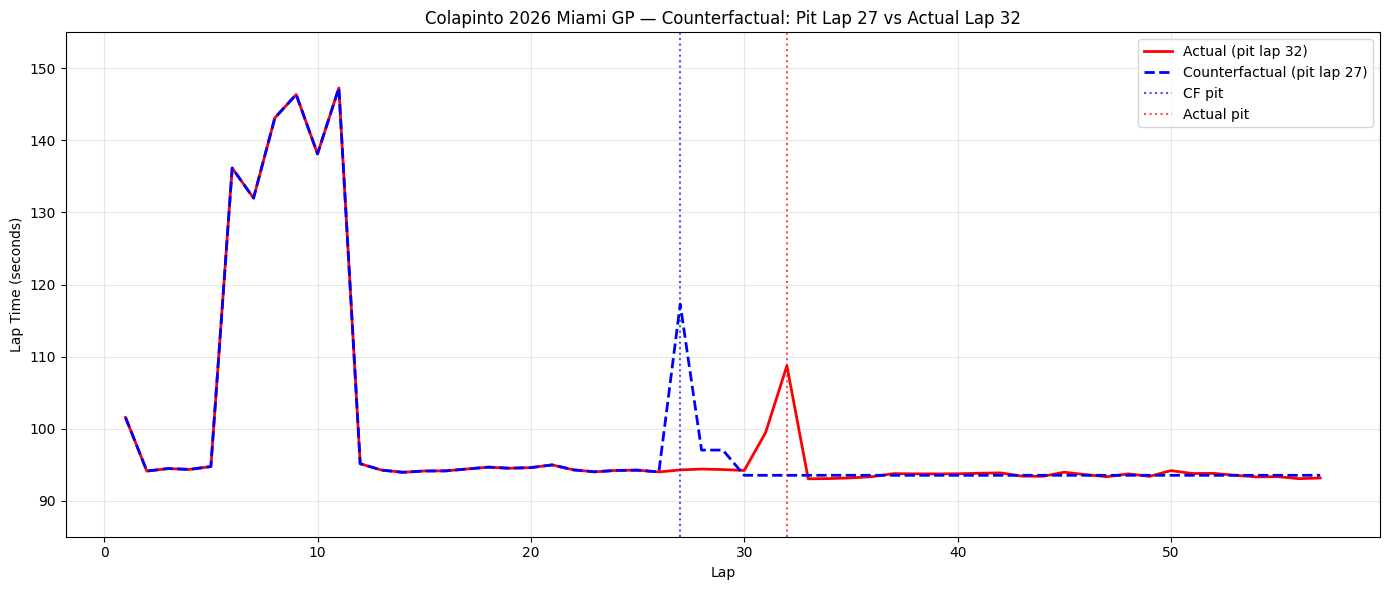

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

actual_laptimes = {
    1:101.556, 2:94.113, 3:94.460, 4:94.339, 5:94.736,
    6:136.173, 7:131.996, 8:143.127, 9:146.366, 10:138.133,
    11:147.279, 12:95.134, 13:94.246, 14:93.941, 15:94.124,
    16:94.137, 17:94.400, 18:94.654, 19:94.505, 20:94.591,
    21:94.967, 22:94.275, 23:94.009, 24:94.203, 25:94.237,
    26:93.991, 27:94.275, 28:94.391, 29:94.323, 30:94.192,
    31:99.432, 32:108.726, 33:93.035, 34:93.070, 35:93.162,
    36:93.341, 37:93.756, 38:93.724, 39:93.717, 40:93.734,
    41:93.803, 42:93.859, 43:93.416, 44:93.384, 45:93.951,
    46:93.612, 47:93.332, 48:93.721, 49:93.380, 50:94.176,
    51:93.775, 52:93.791, 53:93.528, 54:93.304, 55:93.335,
    56:93.059, 57:93.148
}

PIT_LOSS = 23.0
CF_PIT_LAP = 27
ACTUAL_PIT_LAP = 32
WARMUP_LAPS = 2
TOTAL_LAPS = 57

hard_pace = np.mean([actual_laptimes[i] for i in range(33, 58) if i not in []])
warmup_pace = hard_pace + 3.5

actual_total = sum(actual_laptimes.values())

cf_laptimes = {}
cf_total = 0

for lap in range(1, TOTAL_LAPS + 1):
    if lap < CF_PIT_LAP:
        cf_laptimes[lap] = actual_laptimes[lap]
    elif lap == CF_PIT_LAP:
        cf_laptimes[lap] = actual_laptimes[lap] + PIT_LOSS
    elif lap <= CF_PIT_LAP + WARMUP_LAPS:
        cf_laptimes[lap] = warmup_pace
    else:
        tyre_age = lap - CF_PIT_LAP
        cf_laptimes[lap] = hard_pace + (tyre_age * 0.000)
    cf_total += cf_laptimes[lap]

delta = actual_total - cf_total

print(f"Actual total (pit lap 32):        {actual_total:.3f}s")
print(f"Counterfactual (pit lap 27):      {cf_total:.3f}s")
print(f"Delta: {abs(delta):.3f}s")
print(f"Colapinto could have been {'faster' if delta > 0 else 'slower'} by {abs(delta):.1f}s")

laps = list(range(1, TOTAL_LAPS + 1))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(laps, [actual_laptimes[l] for l in laps], label='Actual (pit lap 32)', color='red', linewidth=2)
ax.plot(laps, [cf_laptimes[l] for l in laps], label='Counterfactual (pit lap 27)', color='blue', linewidth=2, linestyle='--')
ax.axvline(x=CF_PIT_LAP, color='blue', linestyle=':', alpha=0.7, label='CF pit')
ax.axvline(x=ACTUAL_PIT_LAP, color='red', linestyle=':', alpha=0.7, label='Actual pit')
ax.set_xlabel('Lap')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Colapinto 2026 Miami GP — Counterfactual: Pit Lap 27 vs Actual Lap 32')
ax.legend()
ax.set_ylim(85, 155)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('colapinto_miami2026.png', dpi=150)
plt.show()

Actual total (pit lap 32):       5661.144s
Counterfactual (pit lap 27):     5668.165s
Delta: 7.021s
Gap to Sainz after pit lap 27:   20.881s
Colapinto still 20.9s behind Sainz


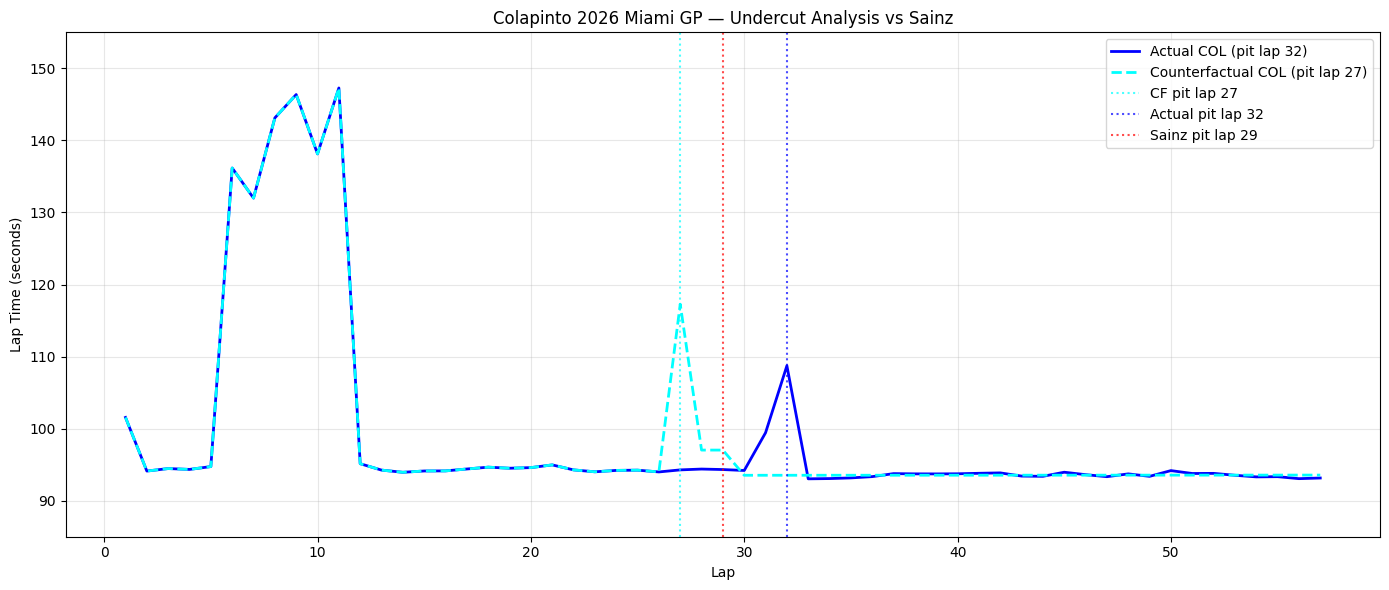

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

actual_laptimes = {
    1:101.556, 2:94.113, 3:94.460, 4:94.339, 5:94.736,
    6:136.173, 7:131.996, 8:143.127, 9:146.366, 10:138.133,
    11:147.279, 12:95.134, 13:94.246, 14:93.941, 15:94.124,
    16:94.137, 17:94.400, 18:94.654, 19:94.505, 20:94.591,
    21:94.967, 22:94.275, 23:94.009, 24:94.203, 25:94.237,
    26:93.991, 27:94.275, 28:94.391, 29:94.323, 30:94.192,
    31:99.432, 32:108.726, 33:93.035, 34:93.070, 35:93.162,
    36:93.341, 37:93.756, 38:93.724, 39:93.717, 40:93.734,
    41:93.803, 42:93.859, 43:93.416, 44:93.384, 45:93.951,
    46:93.612, 47:93.332, 48:93.721, 49:93.380, 50:94.176,
    51:93.775, 52:93.791, 53:93.528, 54:93.304, 55:93.335,
    56:93.059, 57:93.148
}

sainz_laptimes = {
    27:94.601, 28:94.842, 29:108.0,
    30:93.026, 31:93.124, 32:93.236
}

PIT_LOSS = 23.0
CF_PIT_LAP = 27
WARMUP_LAPS = 2
TOTAL_LAPS = 57

hard_pace = np.mean([actual_laptimes[i] for i in range(33, 58)])
warmup_pace = hard_pace + 3.5

actual_total = sum(actual_laptimes.values())

cf_laptimes = {}
cf_total = 0

for lap in range(1, TOTAL_LAPS + 1):
    if lap < CF_PIT_LAP:
        cf_laptimes[lap] = actual_laptimes[lap]
    elif lap == CF_PIT_LAP:
        cf_laptimes[lap] = actual_laptimes[lap] + PIT_LOSS
    elif lap <= CF_PIT_LAP + WARMUP_LAPS:
        cf_laptimes[lap] = warmup_pace
    else:
        tyre_age = lap - CF_PIT_LAP
        cf_laptimes[lap] = hard_pace + (tyre_age * 0.001)
    cf_total += cf_laptimes[lap]

col_gap_to_sainz = 7.0
for lap in range(CF_PIT_LAP, CF_PIT_LAP + 3):
    if lap in sainz_laptimes and lap in cf_laptimes:
        col_gap_to_sainz += cf_laptimes[lap] - sainz_laptimes[lap]

print(f"Actual total (pit lap 32):       {actual_total:.3f}s")
print(f"Counterfactual (pit lap 27):     {cf_total:.3f}s")
print(f"Delta: {abs(actual_total - cf_total):.3f}s")
print(f"Gap to Sainz after pit lap 27:   {col_gap_to_sainz:.3f}s")
if col_gap_to_sainz < 0:
    print("Colapinto AHEAD of Sainz after undercut!")
else:
    print(f"Colapinto still {col_gap_to_sainz:.1f}s behind Sainz")

laps = list(range(1, TOTAL_LAPS + 1))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(laps, [actual_laptimes[l] for l in laps], label='Actual COL (pit lap 32)', color='blue', linewidth=2)
ax.plot(laps, [cf_laptimes[l] for l in laps], label='Counterfactual COL (pit lap 27)', color='cyan', linewidth=2, linestyle='--')
ax.axvline(x=CF_PIT_LAP, color='cyan', linestyle=':', alpha=0.7, label='CF pit lap 27')
ax.axvline(x=32, color='blue', linestyle=':', alpha=0.7, label='Actual pit lap 32')
ax.axvline(x=29, color='red', linestyle=':', alpha=0.7, label='Sainz pit lap 29')
ax.set_xlabel('Lap')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Colapinto 2026 Miami GP — Undercut Analysis vs Sainz')
ax.legend()
ax.set_ylim(85, 155)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('colapinto_undercut_miami2026.png', dpi=150)
plt.show()

Actual total COL (pit lap 32):       5661.144s
Counterfactual COL (pit lap 29):     5669.771s
Delta: 8.627s
Colapinto could have been slower by 8.6s

Gap COL to SAI after pit lap 29: 22.8s
Colapinto 22.8s behind Sainz


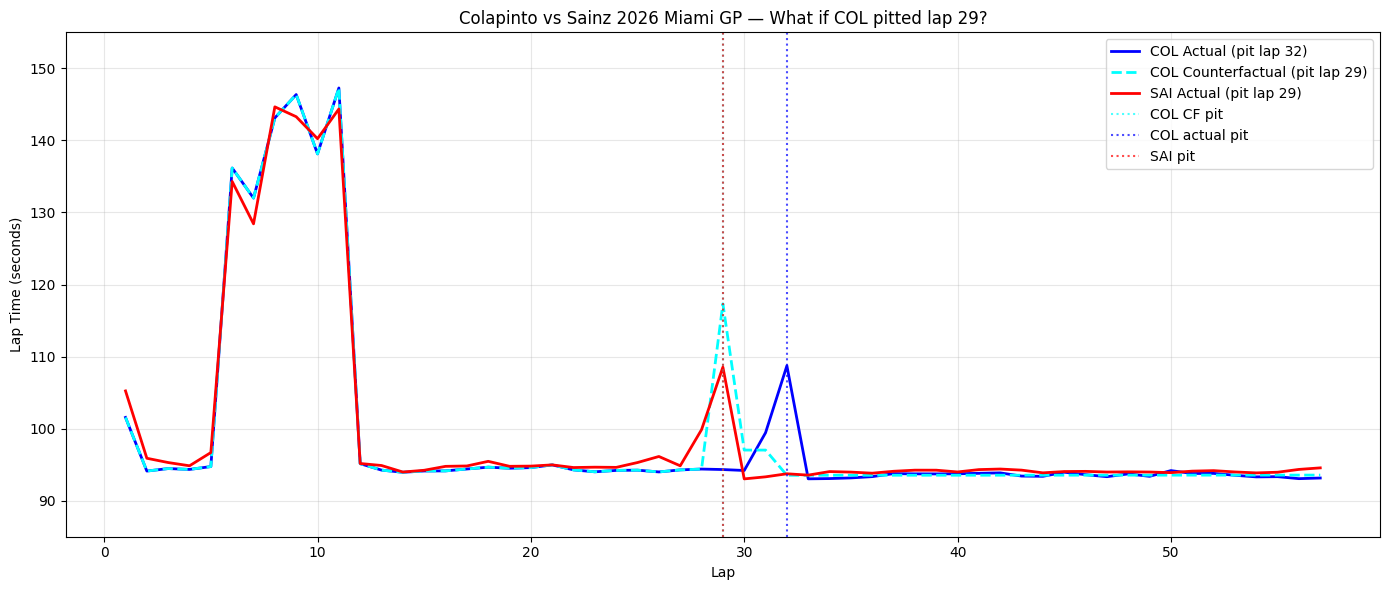

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

col_actual = {
    1:101.556, 2:94.113, 3:94.460, 4:94.339, 5:94.736,
    6:136.173, 7:131.996, 8:143.127, 9:146.366, 10:138.133,
    11:147.279, 12:95.134, 13:94.246, 14:93.941, 15:94.124,
    16:94.137, 17:94.400, 18:94.654, 19:94.505, 20:94.591,
    21:94.967, 22:94.275, 23:94.009, 24:94.203, 25:94.237,
    26:93.991, 27:94.275, 28:94.391, 29:94.323, 30:94.192,
    31:99.432, 32:108.726, 33:93.035, 34:93.070, 35:93.162,
    36:93.341, 37:93.756, 38:93.724, 39:93.717, 40:93.734,
    41:93.803, 42:93.859, 43:93.416, 44:93.384, 45:93.951,
    46:93.612, 47:93.332, 48:93.721, 49:93.380, 50:94.176,
    51:93.775, 52:93.791, 53:93.528, 54:93.304, 55:93.335,
    56:93.059, 57:93.148
}

sai_actual = {
    1:105.235, 2:95.889, 3:95.295, 4:94.844, 5:96.681,
    6:134.301, 7:128.424, 8:144.658, 9:143.290, 10:140.239,
    11:144.363, 12:95.161, 13:94.884, 14:93.978, 15:94.223,
    16:94.767, 17:94.819, 18:95.463, 19:94.773, 20:94.800,
    21:94.968, 22:94.601, 23:94.651, 24:94.624, 25:95.297,
    26:96.136, 27:94.842, 28:99.860, 29:108.534, 30:93.026,
    31:93.311, 32:93.737, 33:93.547, 34:94.042, 35:93.968,
    36:93.818, 37:94.082, 38:94.237, 39:94.234, 40:93.988,
    41:94.315, 42:94.394, 43:94.241, 44:93.866, 45:94.046,
    46:94.070, 47:93.978, 48:94.004, 49:93.980, 50:93.893,
    51:94.102, 52:94.172, 53:93.989, 54:93.858, 55:93.951,
    56:94.341, 57:94.555
}

PIT_LOSS = 23.0
CF_PIT_LAP = 29
WARMUP_LAPS = 2
TOTAL_LAPS = 57

hard_pace = np.mean([col_actual[i] for i in range(33, 58)])
warmup_pace = hard_pace + 3.5

actual_total = sum(col_actual.values())

cf_laptimes = {}
cf_total = 0

for lap in range(1, TOTAL_LAPS + 1):
    if lap < CF_PIT_LAP:
        cf_laptimes[lap] = col_actual[lap]
    elif lap == CF_PIT_LAP:
        cf_laptimes[lap] = col_actual[lap] + PIT_LOSS
    elif lap <= CF_PIT_LAP + WARMUP_LAPS:
        cf_laptimes[lap] = warmup_pace
    else:
        tyre_age = lap - CF_PIT_LAP
        cf_laptimes[lap] = hard_pace + (tyre_age * 0.001)
    cf_total += cf_laptimes[lap]

delta = actual_total - cf_total

print(f"Actual total COL (pit lap 32):       {actual_total:.3f}s")
print(f"Counterfactual COL (pit lap 29):     {cf_total:.3f}s")
print(f"Delta: {abs(delta):.3f}s")
print(f"Colapinto could have been {'faster' if delta > 0 else 'slower'} by {abs(delta):.1f}s")

col_gap_to_sai = 6.5
for lap in range(CF_PIT_LAP, CF_PIT_LAP + 4):
    col_gap_to_sai += cf_laptimes[lap] - sai_actual[lap]

print(f"\nGap COL to SAI after pit lap 29: {col_gap_to_sai:.1f}s")
if col_gap_to_sai < 0:
    print("Colapinto AHEAD of Sainz!")
else:
    print(f"Colapinto {col_gap_to_sai:.1f}s behind Sainz")

laps = list(range(1, TOTAL_LAPS + 1))
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(laps, [col_actual[l] for l in laps], label='COL Actual (pit lap 32)', color='blue', linewidth=2)
ax.plot(laps, [cf_laptimes[l] for l in laps], label='COL Counterfactual (pit lap 29)', color='cyan', linewidth=2, linestyle='--')
ax.plot(laps, [sai_actual[l] for l in laps], label='SAI Actual (pit lap 29)', color='red', linewidth=2)
ax.axvline(x=CF_PIT_LAP, color='cyan', linestyle=':', alpha=0.7, label='COL CF pit')
ax.axvline(x=32, color='blue', linestyle=':', alpha=0.7, label='COL actual pit')
ax.axvline(x=29, color='red', linestyle=':', alpha=0.7, label='SAI pit')
ax.set_xlabel('Lap')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Colapinto vs Sainz 2026 Miami GP — What if COL pitted lap 29?')
ax.legend()
ax.set_ylim(85, 155)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('col_vs_sai_miami2026.png', dpi=150)
plt.show()